# 🎬 Netflix Movies & TV Shows Data Analysis

### Exploratory Data Analysis using Python

**Tools:** Python, NumPy, Pandas, Matplotlib, Seaborn

This project explores the Netflix Movies and TV Shows dataset to identify patterns in content types, release years, countries, genres, ratings, movie durations, and Indian content.

#Phase 1
Setup and load dataset

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
sns.set_theme()

In [100]:
df = pd.read_csv('/content/netflix_titles.csv')

In [101]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#PHASE 2
Understand the Dataset

In [102]:
df.shape

(8807, 12)

In [103]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [105]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [106]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [107]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [108]:
df["rating"].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [109]:
df["release_year"].unique()

array([2020, 2021, 1993, 2018, 1996, 1998, 1997, 2010, 2013, 2017, 1975,
       1978, 1983, 1987, 2012, 2001, 2014, 2002, 2003, 2004, 2011, 2008,
       2009, 2007, 2005, 2006, 1994, 2015, 2019, 2016, 1982, 1989, 1990,
       1991, 1999, 1986, 1992, 1984, 1980, 1961, 2000, 1995, 1985, 1976,
       1959, 1988, 1981, 1972, 1964, 1945, 1954, 1979, 1958, 1956, 1963,
       1970, 1973, 1925, 1974, 1960, 1966, 1971, 1962, 1969, 1977, 1967,
       1968, 1965, 1946, 1942, 1955, 1944, 1947, 1943])

In [110]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [111]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
show_id,0.00
type,0.00
title,0.00
director,29.91
cast,9.37
country,9.44
date_added,0.11
release_year,0.00
rating,0.05
duration,0.03


In [112]:
df.duplicated().sum()

np.int64(0)

#PHASE 3
Data Cleaning

In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df = df.drop_duplicates()

In [115]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [116]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [117]:
df['director']=df['director'].fillna('Unknown')

In [118]:
df['cast']=df['cast'].fillna('Unknown')

In [119]:
df['rating']=df['rating'].fillna('Unknown')

In [120]:
df['country']=df['country'].fillna('Unknown')


In [121]:
df['duration']=df['duration'].fillna('Unknown')

In [122]:
df['date_added']=df['date_added'].fillna('Unknown')

In [123]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

In [124]:
df["year_added"] = df["date_added"].dt.year

In [125]:
movies = df[df["type"] == "Movie"].copy()

In [126]:
movies["duration_min"] = ( movies["duration"].str.extract(r"(\d+)").astype(float) )

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8709 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 894.6+ KB


In [128]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


In [129]:
df.duplicated().sum()

np.int64(0)

In [130]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [131]:
df["type"].value_counts(normalize=True) * 100

,proportion
type,
Movie,69.615079
TV Show,30.384921


### Insight

Movies dominate the Netflix dataset, accounting for approximately 68.6% of all titles, while TV Shows account for approximately 31.3%.

#PHASE 4
Exploratory Data Analysis

In [132]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


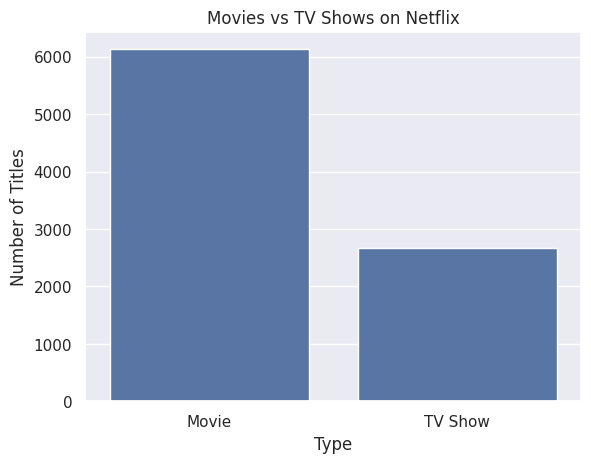

In [133]:
sns.countplot(data=df, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.show()

In [134]:
year_counts = df["release_year"].value_counts().sort_index()
year_counts

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


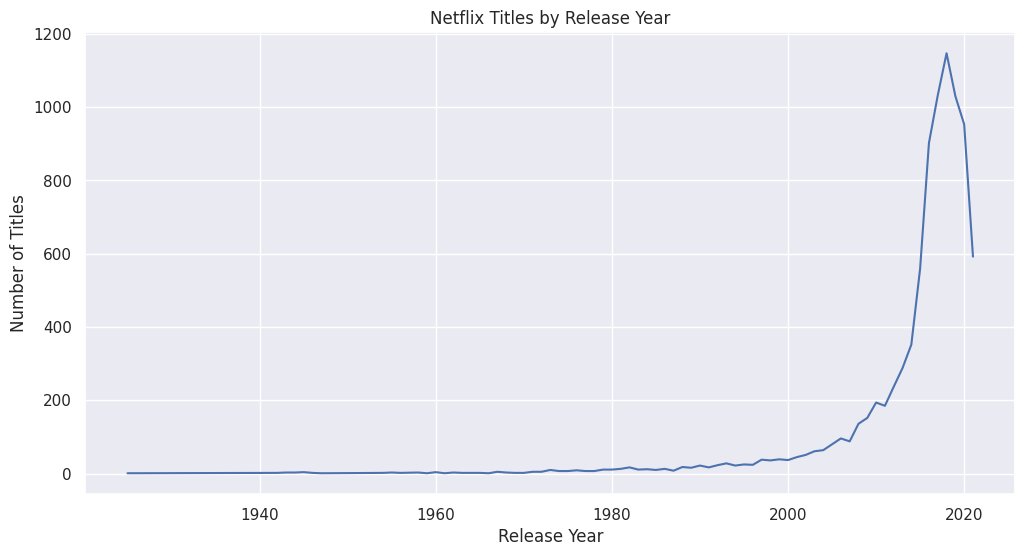

In [135]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values
)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [136]:
added = df["year_added"].value_counts().sort_index()
added

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


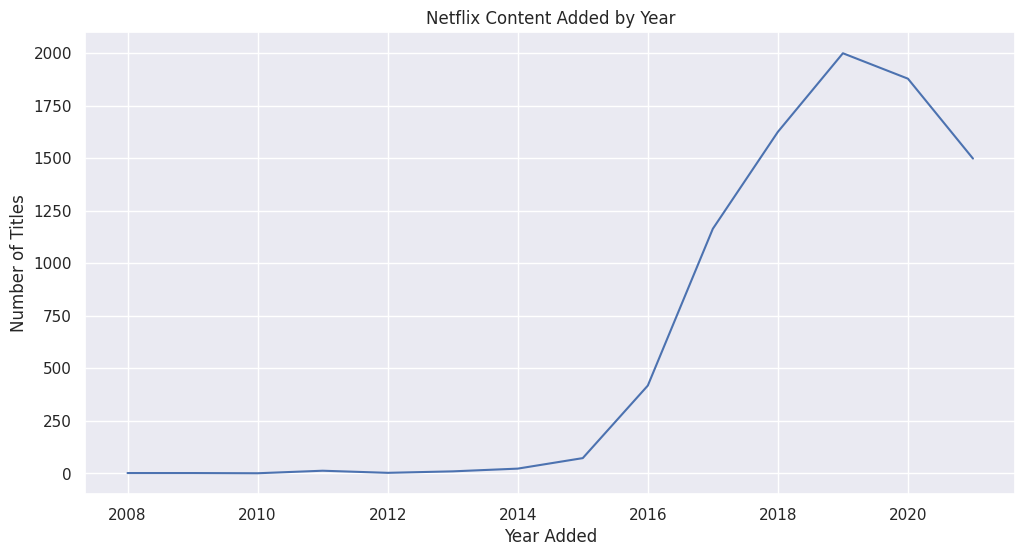

In [137]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=added.index,
    y=added.values
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.show()

In [138]:
countries = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

In [139]:
countries=countries[countries != 'Unknown']
top_countries = countries.value_counts().head(10)

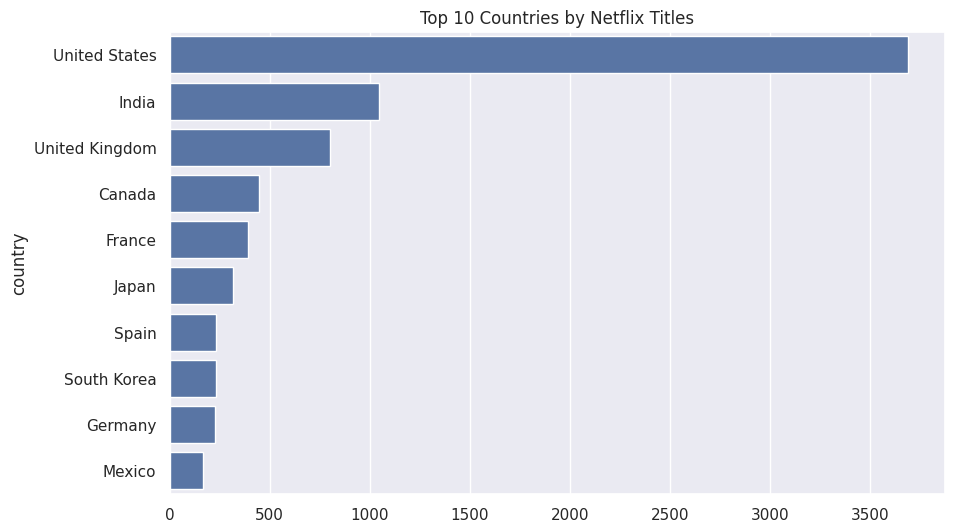

In [140]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Titles")

plt.show()

In [141]:
genres = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

In [142]:
top_genres = genres.value_counts().head(10)

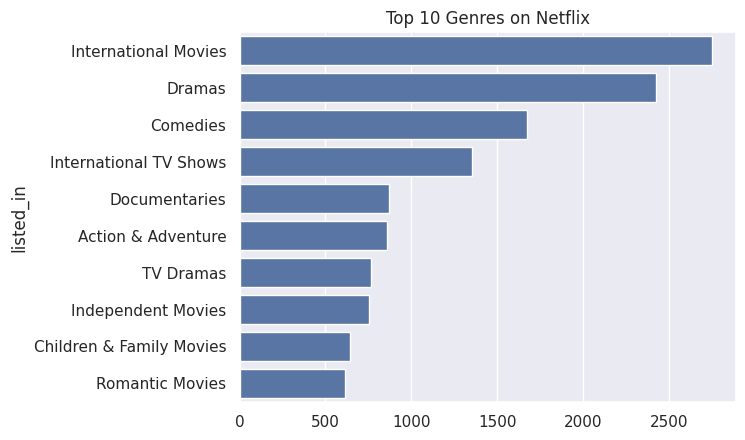

In [143]:
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")

plt.show()

In [144]:
df["rating"].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


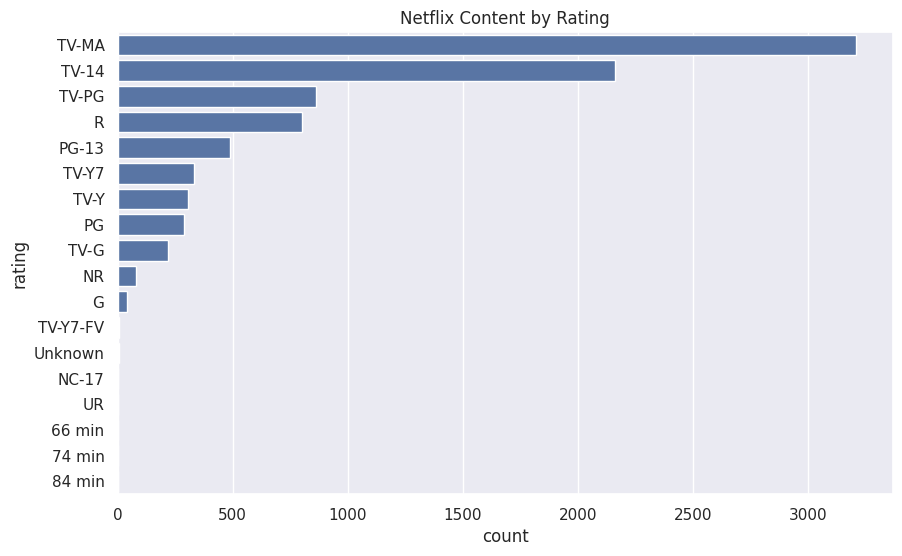

In [145]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)

plt.title("Netflix Content by Rating")

plt.show()

In [146]:
movies["duration_min"].describe()

,duration_min
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


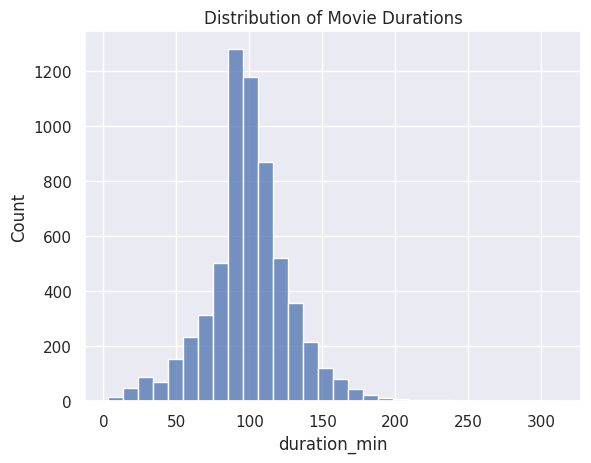

In [147]:
sns.histplot(
    data=movies,
    x="duration_min",
    bins=30
)

plt.title("Distribution of Movie Durations")

plt.show()

In [148]:
directors = (
    df["director"]
    .dropna()
    .str.split(", ")
    .explode()
)

In [149]:
directors=directors.value_counts().head(10)

#PHASE 5
Advanced Analysis

In [150]:
india_df = df[df["country"].str.contains("India", na=False)]

In [151]:
india_df["type"].value_counts()

,count
type,
Movie,962
TV Show,84


In [152]:
india_df["release_year"].value_counts().sort_index()

,count
release_year,
1959,1
1960,1
1962,1
1964,1
1966,1
1969,1
1971,2
1972,2
1973,2


In [153]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0


In [154]:
df['listed_in'].value_counts()

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
...,...
"Action & Adventure, Cult Movies",1
"Action & Adventure, Comedies, Music & Musicals",1
"Classic Movies, Horror Movies, Thrillers",1


In [155]:
df['director'].value_counts()

,count
director,
Unknown,2634
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
...,...
"Milla Harrison-Hansley, Alicky Sussman",1
Drew Stone,1
Benjamin Turner,1


In [156]:
type_year = pd.crosstab(df["year_added"],df["type"])
type_year

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,4
2014.0,19,4
2015.0,56,17
2016.0,253,165


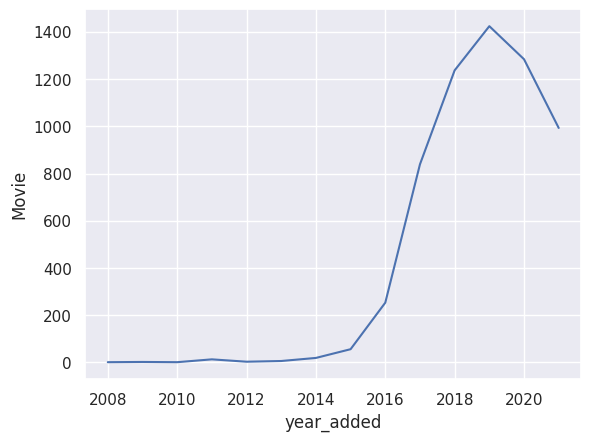

In [157]:
sns.lineplot(data=type_year,x=type_year.index,y=type_year["Movie"])
plt.show()

In [158]:
df_exploded = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')

In [159]:
df_exploded['genre'] = df_exploded['genre'].str.strip()

In [160]:
genre_counts = pd.crosstab(df_exploded['genre'], df_exploded['type'])

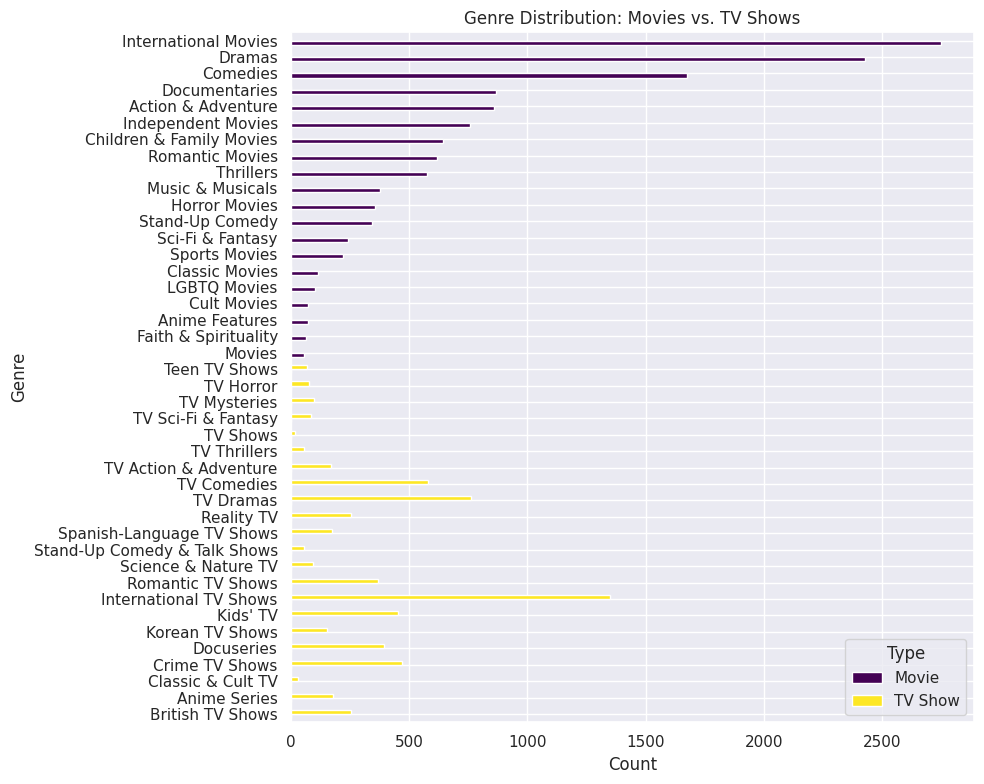

In [161]:
# Plotting top genres by type
gc=genre_counts.sort_values(by='Movie', ascending=True)
gc.plot(kind='barh', figsize=(10, 8), colormap='viridis')
plt.title('Genre Distribution: Movies vs. TV Shows')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

In [162]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

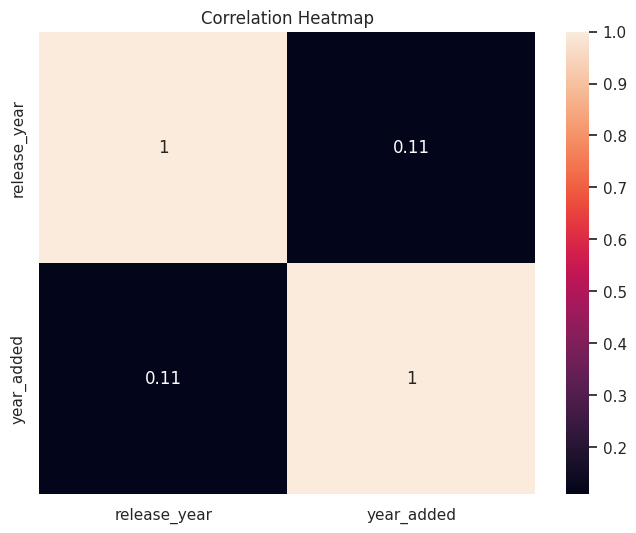

In [163]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True)

plt.title("Correlation Heatmap")

plt.show()

#PHASE 6 Insights & Conclusion

In [164]:
df["release_year"].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


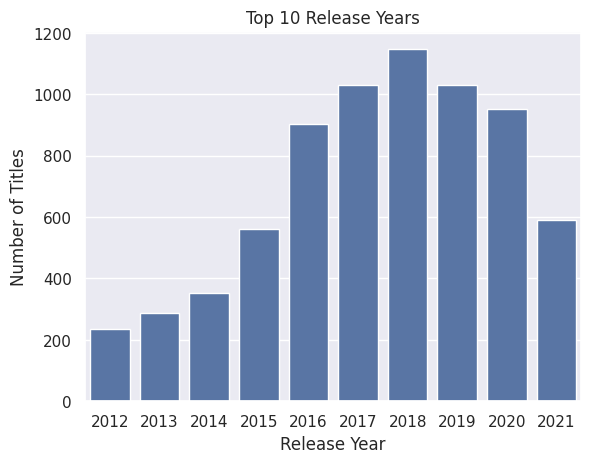

In [165]:
release_year_counts = df["release_year"].value_counts().head(10).reset_index()
release_year_counts.columns = ['release_year', 'count']
sns.barplot(data=release_year_counts, x='release_year', y='count')

plt.title("Top 10 Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### Insight

2018 had the highest number of titles in the dataset, with 1,094 titles, followed by 2019 with 1,013 and 2020 with 953 titles. The number of titles released is substantially lower after 2020, with 591 titles in 2021.

### Insight

The dataset contains a large concentration of titles released in recent years, indicating that Netflix's catalog contains a substantial amount of relatively recent content.

In [166]:
df["year_added"].value_counts().sort_index()

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


In [167]:
df["year_added"].value_counts().head()

,count
year_added,
2019.0,1999
2020.0,1878
2018.0,1625
2021.0,1498
2017.0,1164


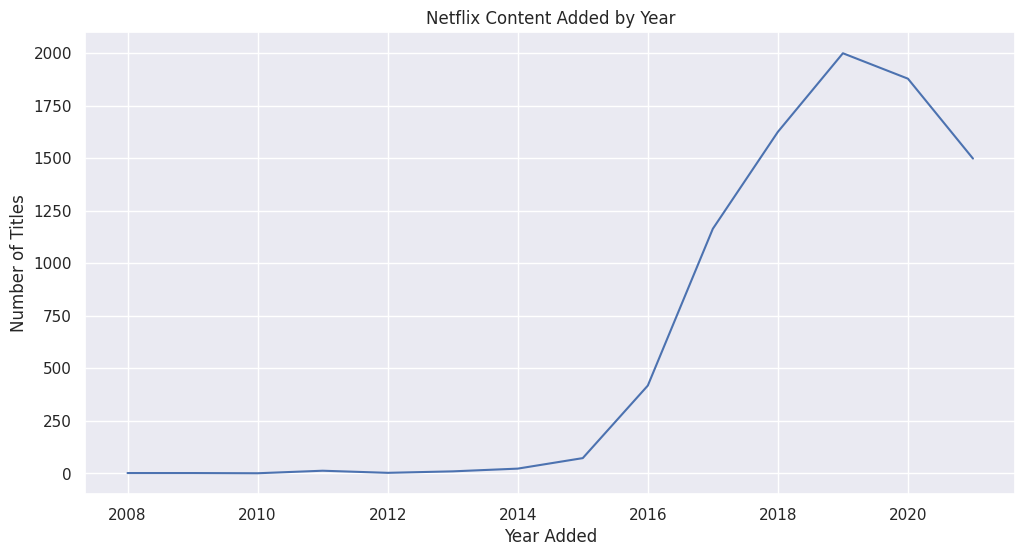

In [168]:
plt.figure(figsize=(12,6))
sns.lineplot(
    x=added.index,
    y=added.values
)
plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

### Insight

Netflix added a significantly larger number of titles during certain years, indicating periods of rapid catalog expansion.

In [169]:
top_countries

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


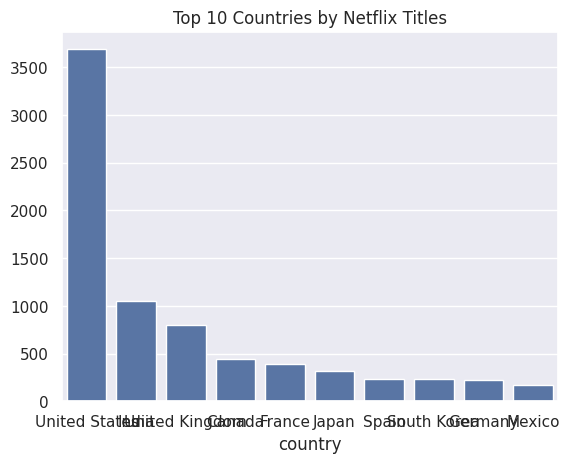

In [170]:
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries by Netflix Titles")
plt.show()

### Insight

The United States is the largest contributor of titles in the dataset, followed by India and the United Kingdom. This indicates that Netflix's catalog has strong representation from the US as well as other major content-producing countries.

In [171]:
top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


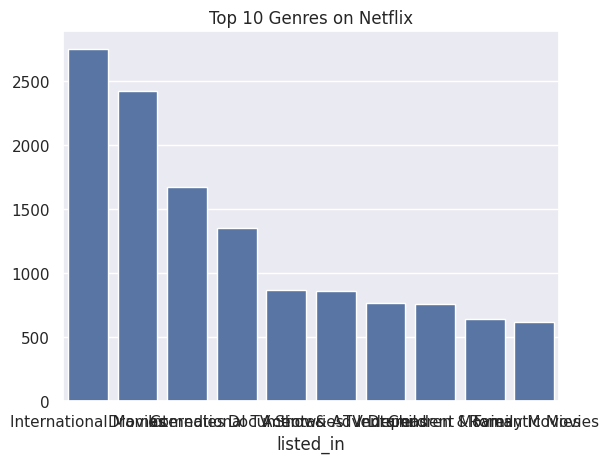

In [172]:
sns.barplot(x=top_genres.index, y=top_genres.values)
plt.title("Top 10 Genres on Netflix")
plt.show()

### Insight

The most common genres in the Netflix catalog are International Movies, Dramas, and Comedies. This indicates that Netflix's catalog has strong representation in these content categories.

In [173]:
df["rating"].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


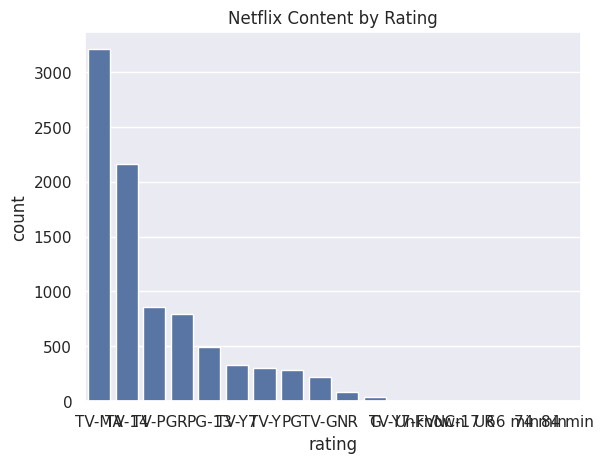

In [174]:
sns.countplot(data=df, x="rating", order=df["rating"].value_counts().index)
plt.title("Netflix Content by Rating")
plt.show()

### Insight

The Netflix catalog contains a wide range of content ratings, with TV-MA being the most common rating in the dataset.

In [175]:
movies["duration_min"].describe()

,duration_min
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


### Insight

The median movie duration is approximately 98 minutes, indicating that a typical movie in the dataset is around 1.5–2 hours long.

In [176]:
india_df["type"].value_counts()

,count
type,
Movie,962
TV Show,84


In [177]:
india_genres = (
    india_df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

india_genres.value_counts().head(10)

,count
listed_in,
International Movies,864
Dramas,662
Comedies,323
Independent Movies,167
Action & Adventure,137
Romantic Movies,120
Music & Musicals,96
Thrillers,92
International TV Shows,66


In [178]:
india_df["release_year"].value_counts().sort_index()

,count
release_year,
1959,1
1960,1
1962,1
1964,1
1966,1
1969,1
1971,2
1972,2
1973,2


### Insight

Indian titles form an important part of the Netflix catalog. The Indian subset contains both Movies and TV Shows, with Movies being more common. The most frequently represented genres include International Movies, Dramas, and Comedies.

# Key Insights

1. Movies dominate the Netflix dataset, accounting for approximately 68.6% of all titles, while TV Shows account for approximately 31.3%.

2. The catalog contains a large concentration of titles released in recent years.

3. The United States is the largest country represented in the dataset, followed by India.

4. International Movies, Dramas, and Comedies are among the most frequently represented genres.

5. TV-MA is the most common content rating.

6. The median movie duration is approximately 98 minutes.

7. Indian content represents an important portion of the dataset, with Movies being more common than TV Shows, and frequently features genres like International Movies, Dramas, and Comedies.

## Business Observations

- Netflix has a larger number of Movies than TV Shows in this dataset.
- The catalog has strong representation from the United States and India.
- The diversity of genres suggests that Netflix targets different audience preferences.
- The growth in titles added during certain years indicates periods of aggressive catalog expansion.

## Limitations

1. The dataset represents a snapshot of Netflix's catalog and may not represent the current catalog.

2. Some records have missing date information.

3. Some titles contain multiple countries and genres, which requires splitting the values for analysis.

4. The analysis describes patterns in the dataset but does not establish causal relationships.

5. The dataset does not contain information such as viewer ratings, watch time, revenue, or popularity.

## Conclusion

This project analyzed the Netflix Movies and TV Shows dataset using Python, NumPy, Pandas, Matplotlib, and Seaborn. The analysis explored content types, release years, countries, genres, ratings, movie durations, and Indian content.

The analysis showed that Movies represent the majority of titles in the dataset, while the United States and India are among the most strongly represented countries. The project also revealed patterns in Netflix's content distribution, genres, ratings, and movie durations.

Overall, this project provided practical experience in data cleaning, exploratory data analysis, data visualization, and extracting meaningful insights from a real-world dataset.

In [179]:
df["release_year"].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


In [180]:
df["year_added"].value_counts().head(10)

,count
year_added,
2019.0,1999
2020.0,1878
2018.0,1625
2021.0,1498
2017.0,1164
2016.0,418
2015.0,73
2014.0,23
2011.0,13
